# Assignment 3

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [55]:
# Load the libraries as required.
import pandas as pd

In [56]:
# Load data
columns = ['coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area']
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt


,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


# Get X and Y

Create the features data frame and target data.

In [57]:
X = fires_dt.drop(columns=['area']) 
Y = fires_dt['area'] 

In [58]:
print("Features shape:", X.shape)
print("Target shape:", Y.shape)

Features shape: (517, 12)
Target shape: (517,)


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

numeric_features = ["coord_x", "coord_y", "ffmc", "dmc", "dc", "isi", "temp", "rh", "wind", "rain"]
categorical_features = ["month", "day"]

preproc1 = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_features), 
        ("cat", OneHotEncoder(handle_unknown="ignore"), 
         categorical_features)])

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [60]:
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline

preproc2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("scale", RobustScaler()),  
            ("transform", PowerTransformer())  
        ]), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)])

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [61]:
# Pipeline A = preproc1 + baseline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

pipeline_A = Pipeline([
    ("preprocessing", preproc1),
    ("regressor", KNeighborsRegressor())
])

scores_A = cross_val_score(pipeline_A, X, Y, scoring="neg_mean_absolute_error", cv=5)

print(-scores_A.mean())

24.45259914115011


In [62]:
# Pipeline B = preproc2 + baseline
pipeline_B = Pipeline([
    ("preprocessing", preproc2),
    ("regressor", KNeighborsRegressor())
])

scores_B = cross_val_score(pipeline_B, X, Y, scoring="neg_mean_absolute_error", cv=5)

print(-scores_B.mean())

24.100343129200898


In [63]:
# Pipeline C = preproc1 + advanced model

pipeline_C = Pipeline([
    ("preprocessing", preproc1),
    ("regressor", RandomForestRegressor(random_state=42))
])

scores_C = cross_val_score(pipeline_C, X, Y, scoring="neg_mean_absolute_error", cv=5)

print(-scores_C.mean())

26.16050905109534


In [64]:
# Pipeline D = preproc2 + advanced model
pipeline_D = Pipeline([
    ("preprocessing", preproc2),
    ("regressor", RandomForestRegressor(random_state=42))
])

scores_D = cross_val_score(pipeline_D, X, Y, scoring="neg_mean_absolute_error", cv=5)

print(-scores_D.mean())

25.66198533501369


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [65]:
from sklearn.model_selection import GridSearchCV, cross_val_score

param_grid_A = {"regressor__n_neighbors": [1, 5, 10, 15, 20],"regressor__weights": ["uniform", "distance"],"regressor__p": [1, 2]}
grid_search_A = GridSearchCV(pipeline_A, param_grid_A, scoring="neg_mean_absolute_error", cv=5)
grid_search_A.fit(X, Y)

print(grid_search_A.best_params_)
print(-grid_search_A.best_score_)

{'regressor__n_neighbors': 15, 'regressor__p': 2, 'regressor__weights': 'uniform'}
22.374028914612893


In [66]:
param_grid_B = {"regressor__n_neighbors": [1, 5, 10, 15, 20],"regressor__weights": ["uniform", "distance"],"regressor__p": [1, 2]}
grid_search_B = GridSearchCV(pipeline_B, param_grid_B, scoring="neg_mean_absolute_error", cv=5)
grid_search_B.fit(X, Y)

print(grid_search_B.best_params_)
print(-grid_search_B.best_score_)

{'regressor__n_neighbors': 15, 'regressor__p': 2, 'regressor__weights': 'uniform'}
22.76632486930545


In [67]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

param_distributions = {
    "regressor__n_estimators": [100, 250, 500],
    "regressor__max_depth": [2, 10, 15],
    "regressor__min_samples_split": [2, 10, 15],
    "regressor__min_samples_leaf": [2, 10, 15],
    "regressor__bootstrap": [True, False]
}

random_search = RandomizedSearchCV(pipeline_C, param_distributions, n_iter=20, scoring="neg_mean_absolute_error", cv=5, random_state=42, n_jobs=-1)
random_search.fit(X, Y)

best_pipeline_C = random_search.best_estimator_
best_score_C = -random_search.best_score_
scores_C = cross_val_score(best_pipeline_C, X, Y, scoring="neg_mean_absolute_error", cv=5)

print( -scores_C.mean())
print(random_search.best_params_)

20.796873971119645
{'regressor__n_estimators': 250, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 15, 'regressor__max_depth': 2, 'regressor__bootstrap': True}


In [68]:

param_distributions = {
    "regressor__n_estimators": [100, 250, 500],
    "regressor__max_depth": [2, 10, 15],
    "regressor__min_samples_split": [2, 10, 15],
    "regressor__min_samples_leaf": [2, 10, 15],
    "regressor__bootstrap": [True, False]
}

random_search = RandomizedSearchCV(pipeline_D, param_distributions, n_iter=20, scoring="neg_mean_absolute_error", cv=5, random_state=42, n_jobs=-1)
random_search.fit(X, Y)

best_pipeline_D = random_search.best_estimator_
best_score_D = -random_search.best_score_
scores_D = cross_val_score(best_pipeline_D, X, Y, scoring="neg_mean_absolute_error", cv=5)

print( -scores_D.mean())
print(random_search.best_params_)

20.718010905715268
{'regressor__n_estimators': 250, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 15, 'regressor__max_depth': 2, 'regressor__bootstrap': True}


# Evaluate

+ Which model has the best performance?

model D hase the best perfomance due to minimum absolute error 20,71 (vs A-22,37, B-22,76, C-20,79). RandomForestRegressor provide overall better results

# Export

+ Save the best performing model to a pickle file.

In [69]:
import pickle

with open("pipeline_B.pkl", "wb") as f:
    pickle.dump(pipeline_B, f)
   

# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

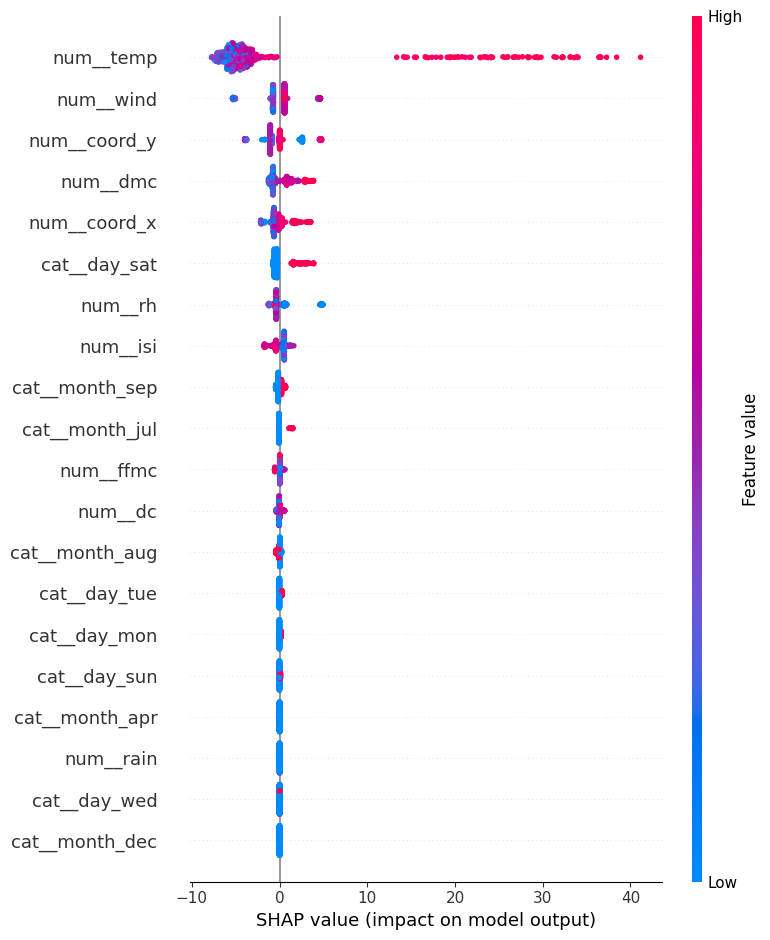

,feature,importance
14,cat__month_jan,0.000000
26,cat__day_thu,0.000000
22,cat__day_fri,0.000000
20,cat__month_oct,0.000000
19,cat__month_nov,0.000000
18,cat__month_may,0.000000
17,cat__month_mar,0.000000
16,cat__month_jun,0.000000
13,cat__month_feb,0.000000
12,cat__month_dec,0.000000


In [70]:
import shap

shap.summary_plot(shap_values_full, best_model["preprocessing"].transform(X), feature_names=transformed_feature_names)

importance_df.sort_values(by='importance', ascending=True, inplace=True)

importance_df

*(Answer here.)*

We have 16 parameters that have a non-zero value -all of them contribute to the forecast. The greatest contribution is made by the features of temperature, wind, and coordinates. From the point of view of the seasonal factor, the non-zero months are July, August, September, and the days of the week - Saturday, Sunday, Monday, Tuesday. In general, it looks like the model describes a situation when people visit the forest on weekends in the summer, and this provokes fires.
 The least contribution is the feature of months, but in total they generate about 0.44, so I would not remove any parameters from the dataset. But if it is necessary to remove one feature, I would remove months  - it is also likely that the months and temperature have a positive correlation, that is - the summer months, the higher temperature, so the feature of the months may be secondary to temperature.


## Criteria

The [rubric](./assignment_3_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-3`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_3.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.